In [2]:
using Pkg
Pkg.activate(".")
Pkg.add(["ITensors","ITensorMPS","Compat","OrdinaryDiffEqTsit5",
        "Graphs","NamedGraphs","SpecialFunctions",
        "Observers","KrylovKit","Plots","DataFrames","HDF5"])

  Activating project at `~/Documents/MacbookPro/TDVP Expansion`
     Project No packages added to or removed from `~/Documents/MacbookPro/TDVP Expansion/Project.toml`
    Manifest No packages added to or removed from `~/Documents/MacbookPro/TDVP Expansion/Manifest.toml`


In [3]:
include("1DExpansion.jl")

In [4]:
function densityheatmap(filename;opts...)
    times=h5read(filename,"times")
    sites=h5read(filename,"sites")
    densities=h5read(filename,"densities")
    heatmap(times,sites,densities;xlabel="t",ylabel="x",opts...)
end 

densityheatmap (generic function with 1 method)

# Dial in parameters

We will take 10 particles in 20 sites, and a hard-wall trap.  It looks like a timestep of 0.1 is fine.  For stronger interactions it is fine to restrict maximum occupation to 3 -- but in the non-interacting case need to take larger local space.  If we make nmax=3 it takes about 25s on my laptop.  With nmax=10 it takes about 43s -- so I'll use the large local Hilbert space, so that I am not having any issues at weak interactions.  I am happy to pay the factor of 2 in time.

finding ground state with 10 particles in a system of length 20
max occupation per site 3, hopping g=1, interactions U=10
redirecting stdout to run10.out
Found ground state in wall time 0.2329699993133545 s.  Energy=-4.584808632784483

Calculating time evolution
Expanding with time independent Hamiltonian
redirecting stdout to run10.out
completed time evolution in wall time 26.287231922149658 s
 26.521665 seconds (317.78 M allocations: 41.469 GiB, 12.44% gc time)


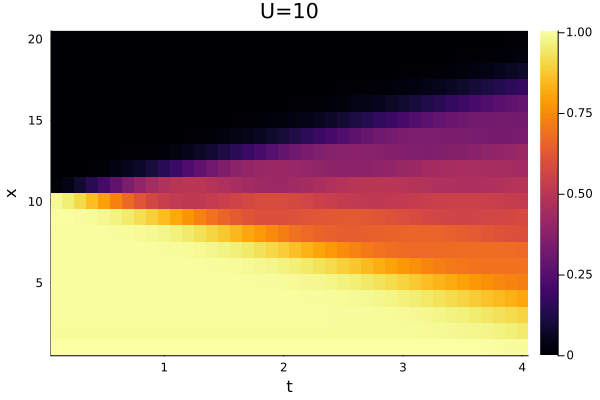

In [62]:
@time run10=tdvpexp(;num=10,trap=well(20;V=30,L=10.5,s=0),
    U=10,time_step=0.1,T=4,maxn=3,verbose=true,
    outputlevel=1,redirectstdout="run10.out");
saveocs(run10,"run10.hdf5")
densityheatmap("run10.hdf5";title="U=10")

finding ground state with 10 particles in a system of length 20
max occupation per site 10, hopping g=1, interactions U=10
redirecting stdout to run10b.out
Found ground state in wall time 0.5090830326080322 s.  Energy=-4.584847858303722

Calculating time evolution
Expanding with time independent Hamiltonian
redirecting stdout to run10b.out
completed time evolution in wall time 42.60690712928772 s
 43.117895 seconds (482.62 M allocations: 62.429 GiB, 11.57% gc time)


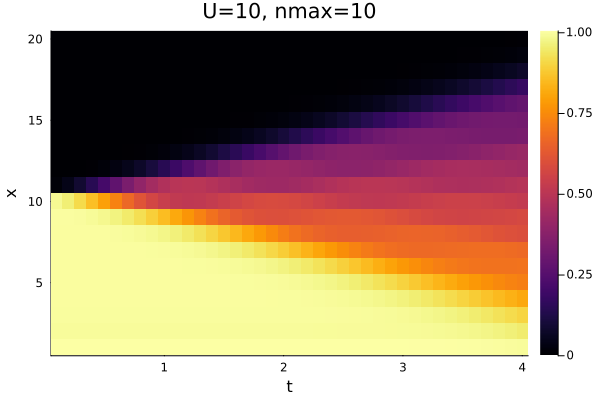

In [59]:
@time run10b=tdvpexp(;num=10,trap=well(20;V=30,L=10.5,s=0),
    U=10,time_step=0.1,T=4,maxn=10,verbose=true,
    outputlevel=1,redirectstdout="run10b.out");
saveocs(run10b,"run10b.hdf5")
densityheatmap("run10b.hdf5";title="U=10, nmax=10")

finding ground state with 10 particles in a system of length 20
max occupation per site 10, hopping g=1, interactions U=1
redirecting stdout to run1.out
Found ground state in wall time 1.806062936782837 s.  Energy=-15.812768947690778

Calculating time evolution
Expanding with time independent Hamiltonian
redirecting stdout to run1.out
completed time evolution in wall time 59.037057876586914 s
 60.845363 seconds (666.05 M allocations: 85.155 GiB, 11.64% gc time)


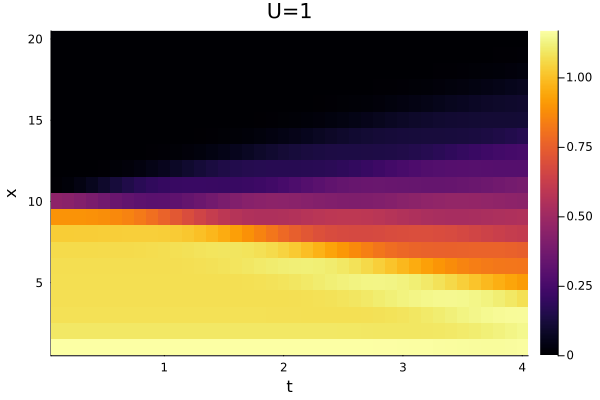

In [60]:
@time run1=tdvpexp(;num=10,trap=well(20;V=30,L=10.5,s=0),
    U=1,time_step=0.1,T=4,maxn=10,verbose=true,
    outputlevel=1,redirectstdout="run1.out");
saveocs(run1,"run1.hdf5")
densityheatmap("run1.hdf5";title="U=1")

finding ground state with 10 particles in a system of length 20
max occupation per site 10, hopping g=1, interactions U=0
redirecting stdout to run0.out
Found ground state in wall time 3.7707839012145996 s.  Energy=-19.777968716323244

Calculating time evolution
Expanding with time independent Hamiltonian
redirecting stdout to run0.out
completed time evolution in wall time 33.48502802848816 s
 37.257346 seconds (308.53 M allocations: 57.405 GiB, 13.99% gc time)


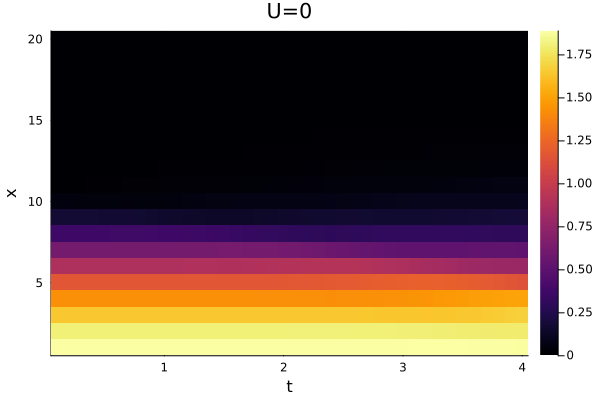

In [54]:
@time run0=tdvpexp(;num=10,trap=well(20;V=30,L=10.5,s=0),
    U=0,time_step=0.1,T=4,maxn=10,verbose=true,
    outputlevel=1,redirectstdout="run0.out");
saveocs(run0,"run0.hdf5")
densityheatmap("run0.hdf5";title="U=0")

finding ground state with 1 particles in a system of length 20
max occupation per site 2, hopping g=1, interactions U=0
redirecting stdout to run00.out
Found ground state in wall time 0.09135293960571289 s.  Energy=-1.9777975693100516

Calculating time evolution
Expanding with time independent Hamiltonian
redirecting stdout to run00.out
completed time evolution in wall time 1.791849136352539 s
  1.883752 seconds (19.25 M allocations: 2.944 GiB, 10.05% gc time)


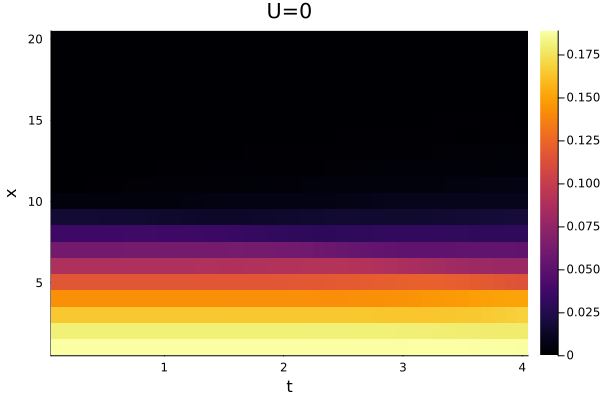

In [55]:
@time run00=tdvpexp(;num=1,trap=well(20;V=30,L=10.5,s=0),
    U=0,time_step=0.1,T=4,maxn=2,verbose=true,
    outputlevel=1,redirectstdout="run00.out");
saveocs(run00,"run00.hdf5")
densityheatmap("run00.hdf5";title="U=0")

finding ground state with 10 particles in a system of length 20
max occupation per site 10, hopping g=1, interactions U=0.5
redirecting stdout to run05.out
Found ground state in wall time 2.413496971130371 s.  Energy=-17.5234868243462

Calculating time evolution
Expanding with time independent Hamiltonian
redirecting stdout to run05.out
completed time evolution in wall time 65.5781261920929 s
 67.994201 seconds (725.19 M allocations: 93.906 GiB, 11.72% gc time)


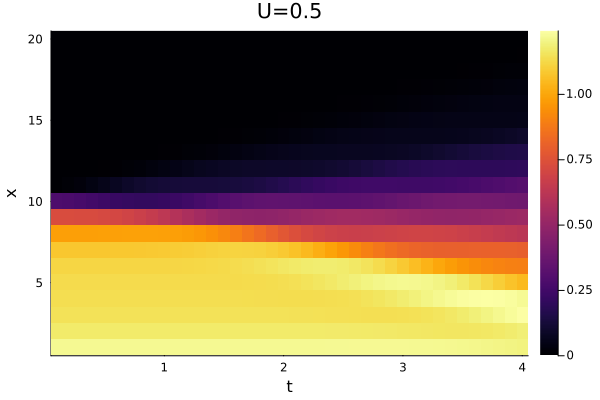

In [58]:
@time run05=tdvpexp(;num=10,trap=well(20;V=30,L=10.5,s=0),
    U=0.5,time_step=0.1,T=4,maxn=10,verbose=true,
    outputlevel=1,redirectstdout="run05.out");
saveocs(run05,"run05.hdf5")
densityheatmap("run05.hdf5";title="U=0.5")

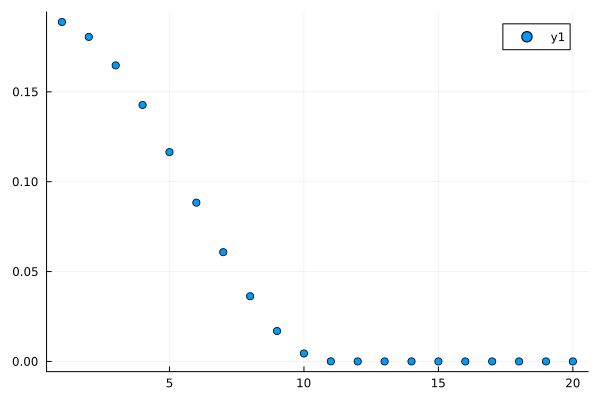

In [56]:
d00=h5read("run00.hdf5","densities");
scatter(d00[:,1])

# Production

In [65]:
for U in 1:10
    println("Starting loop with U=$U")
    root="smallprod$U"
    data=tdvpexp(;num=10,trap=well(20;V=30,L=10.5,s=0),
    U,time_step=0.1,T=4,maxn=10,verbose=true,
    outputlevel=1,redirectstdout=root*".out");
    saveocs(data,root*".hdf5")
    println("*******************************************")
end

Starting loop with U=1
finding ground state with 10 particles in a system of length 20
max occupation per site 10, hopping g=1, interactions U=1
redirecting stdout to smallprod1.out
Found ground state in wall time 2.4368679523468018 s.  Energy=-15.812768947690778

Calculating time evolution
Expanding with time independent Hamiltonian
redirecting stdout to smallprod1.out
completed time evolution in wall time 59.35266304016113 s
*******************************************
Starting loop with U=2
finding ground state with 10 particles in a system of length 20
max occupation per site 10, hopping g=1, interactions U=2
redirecting stdout to smallprod2.out
Found ground state in wall time 1.8620531558990479 s.  Energy=-13.039824533610972

Calculating time evolution
Expanding with time independent Hamiltonian
redirecting stdout to smallprod2.out
completed time evolution in wall time 66.66287899017334 s
*******************************************
Starting loop with U=3
finding ground state with 1

In [66]:
for wU in 0:9
    U=0.1*wU
    println("Starting loop with U=$U")
    root="smallprod0$wU"
    data=tdvpexp(;num=10,trap=well(20;V=30,L=10.5,s=0),
    U,time_step=0.1,T=4,maxn=10,verbose=true,
    outputlevel=1,redirectstdout=root*".out");
    saveocs(data,root*".hdf5")
    println("*******************************************")
end

Starting loop with U=0.0
finding ground state with 10 particles in a system of length 20
max occupation per site 10, hopping g=1, interactions U=0.0
redirecting stdout to smallprod00.out
Found ground state in wall time 3.521611213684082 s.  Energy=-19.777968716323244

Calculating time evolution
Expanding with time independent Hamiltonian
redirecting stdout to smallprod00.out
completed time evolution in wall time 33.16793394088745 s
*******************************************
Starting loop with U=0.1
finding ground state with 10 particles in a system of length 20
max occupation per site 10, hopping g=1, interactions U=0.1
redirecting stdout to smallprod01.out
Found ground state in wall time 3.553987979888916 s.  Energy=-19.22046396917469

Calculating time evolution
Expanding with time independent Hamiltonian
redirecting stdout to smallprod01.out
completed time evolution in wall time 52.86620903015137 s
*******************************************
Starting loop with U=0.2
finding ground s

# Larger

In [68]:
for wU in 0:9
    U=0.1*wU
    println("Starting loop with U=$U")
    root="medprod0$wU"
    data=tdvpexp(;num=20,trap=well(40;V=30,L=20.5,s=0),
    U,time_step=0.1,T=10,maxn=20,verbose=true,
    outputlevel=1,redirectstdout=root*".out");
    saveocs(data,root*".hdf5")
    println("*******************************************")
end

Starting loop with U=0.0
finding ground state with 20 particles in a system of length 40
max occupation per site 20, hopping g=1, interactions U=0.0
redirecting stdout to medprod00.out
Found ground state in wall time 95.69600296020508 s.  Energy=-39.882963525652784

Calculating time evolution
Expanding with time independent Hamiltonian
redirecting stdout to medprod00.out
completed time evolution in wall time 1325.466444015503 s
*******************************************
Starting loop with U=0.1
finding ground state with 20 particles in a system of length 40
max occupation per site 20, hopping g=1, interactions U=0.1
redirecting stdout to medprod01.out
Found ground state in wall time 45.24587798118591 s.  Energy=-38.807764410658926

Calculating time evolution
Expanding with time independent Hamiltonian
redirecting stdout to medprod01.out
completed time evolution in wall time 1206.5464029312134 s
*******************************************
Starting loop with U=0.2
finding ground state w

In [69]:
for U in 1:10
    println("Starting loop with U=$U")
    root="medprod$U"
    data=tdvpexp(;num=20,trap=well(40;V=30,L=20.5,s=0),
    U,time_step=0.1,T=10,maxn=20,verbose=true,
    outputlevel=1,redirectstdout=root*".out");
    saveocs(data,root*".hdf5")
    println("*******************************************")
end

Starting loop with U=1
finding ground state with 20 particles in a system of length 40
max occupation per site 20, hopping g=1, interactions U=1
redirecting stdout to medprod1.out
Found ground state in wall time 15.956187963485718 s.  Energy=-32.10722790046885

Calculating time evolution
Expanding with time independent Hamiltonian
redirecting stdout to medprod1.out
completed time evolution in wall time 787.5965328216553 s
*******************************************
Starting loop with U=2
finding ground state with 20 particles in a system of length 40
max occupation per site 20, hopping g=1, interactions U=2
redirecting stdout to medprod2.out
Found ground state in wall time 8.633917093276978 s.  Energy=-26.471558575970715

Calculating time evolution
Expanding with time independent Hamiltonian
redirecting stdout to medprod2.out
completed time evolution in wall time 695.3721258640289 s
*******************************************
Starting loop with U=3
finding ground state with 20 particle

## Scripts

Rather than running these in a notebook, it is convenient to write scripts that do them

In [75]:
include("1DExpansionScripts.jl")

wUexpscript (generic function with 1 method)

In [77]:
shortscripts=[expscript("short";U=U,num=10,len=20,V=30,time_step=0.1,T=4)
    for U in 1:10]

10-element Vector{String}:
 "short1.jl"
 "short2.jl"
 "short3.jl"
 "short4.jl"
 "short5.jl"
 "short6.jl"
 "short7.jl"
 "short8.jl"
 "short9.jl"
 "short10.jl"

In [78]:
shortmaster=masterscript("shortmaster",shortscripts)

"shortmaster"

Put the master script, the scripts, "1DExpansion.jl", and the "*.toml" files in a directory.  You can then run the master script to run all the others.

(I actually made a bunch of scripts before-hand by hand, so the actual production runs may follow a slightly different naming convention)

I have a workstation with 64 processors, so this is an efficient lazy man's parallelization.

In [79]:
sshortscripts=[wUexpscript("short",wU=wU,num=10,len=20,V=30,time_step=0.1,T=4) for wU in 0:9]
sshortmaster=masterscript("sshortmaster",sshortscripts)

"short00.jl"

In [ ]:
medscripts=[expscript("med";U=U,num=20,
        len=40,V=30,time_step=0.1,T=10)
    for U in 1:10]
smedscripts=[wUexpscript("med";wU=wU,num=20,
        len=40,V=30,time_step=0.1,T=10)
    for wU in 0:9]
medmaster=masterscript("med",medscripts)
smedmaster=masterscript("smed",smedscripts)

In [ ]:
bigscripts=[expscript("big";U=U,num=40,
        len=80,V=30,time_step=0.1,T=20)
    for U in 1:10]
sbigscripts=[wUexpscript("big";wU=wU,num=40,
        len=80,V=30,time_step=0.1,T=20)
    for wU in 0:9]
bigmaster=masterscript("big",medscripts)
sbigmaster=masterscript("sbig",smedscripts)

# Product State

The old 2012 paper from the Bloch group modeled the initial state by starting with a product state, in stead of relaxing in a trap.

Here is our test of that

In [93]:
include("1DExpansion.jl")

finding ground state with 10 particles in a system of length 20
max occupation per site 3, hopping g=1, interactions U=10
redirecting stdout to run10.out
Found ground state in wall time 0.21228814125061035 s.  Energy=-4.584808632784483

Calculating time evolution
Expanding with time independent Hamiltonian
redirecting stdout to run10.out
completed time evolution in wall time 26.544218063354492 s
 26.757054 seconds (317.77 M allocations: 41.468 GiB, 13.19% gc time)


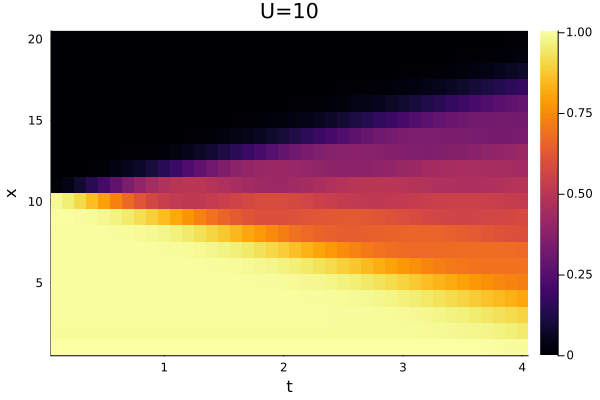

In [86]:
@time run10=tdvpexp(;num=10,
    trap=well(20;V=30,L=10.5,s=0),
    U=10,time_step=0.1,T=4,maxn=3,verbose=true,
    outputlevel=1,redirectstdout="run10.out");
saveocs(run10,"run10.hdf5")
densityheatmap("run10.hdf5";title="U=10")

starting with product state of 10 particles in a system of length 20
max occupation per site 3

Calculating time evolution
Expanding with time independent Hamiltonian
redirecting stdout to prodrun10.out
completed time evolution in wall time 87.2644989490509 s
 87.441005 seconds (574.14 M allocations: 166.024 GiB, 25.13% gc time, 1.21% compilation time: 66% of which was recompilation)


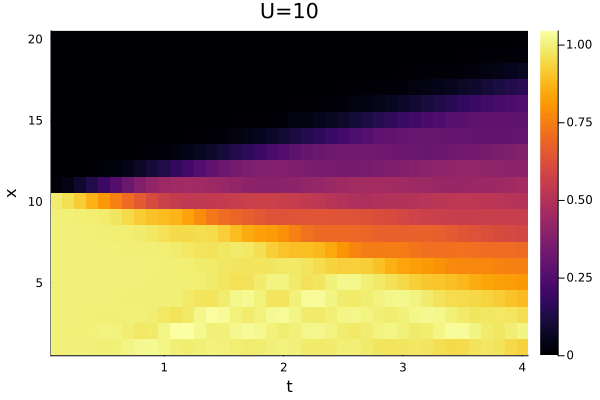

In [94]:
@time prodrun10=prodtdvpexp(;num=10,
    U=10,time_step=0.1,T=4,maxn=3,verbose=true,
    outputlevel=1,maxdim=500,redirectstdout="prodrun10.out");
saveocs(prodrun10,"prodrun10.hdf5")
densityheatmap("prodrun10.hdf5";title="U=10")

Interestingly, the bond dimension grows much much faster here than when we relax before doing the expansion -- so we need to increase `maxdim`.  That probably limits the system sizes we can do.

starting with product state of 10 particles in a system of length 20
max occupation per site 10

Calculating time evolution
Expanding with time independent Hamiltonian
redirecting stdout to prodrun1.out
completed time evolution in wall time 376.4992468357086 s
376.500848 seconds (1.41 G allocations: 626.246 GiB, 28.99% gc time, 0.00% compilation time)


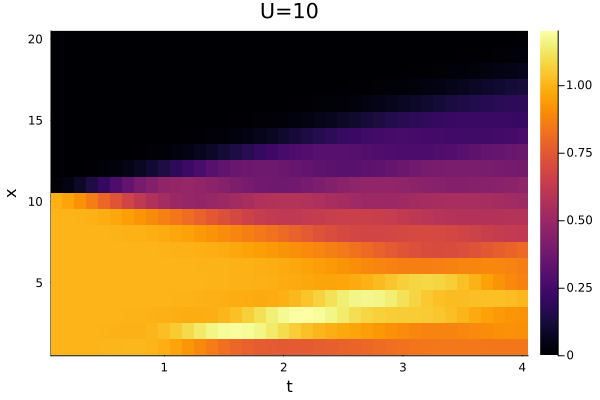

In [97]:
@time prodrun1=prodtdvpexp(;num=10,
    U=1,time_step=0.1,T=4,maxn=10,verbose=true,
    outputlevel=1,maxdim=500,redirectstdout="prodrun1.out");
saveocs(prodrun1,"prodrun1.hdf5")
densityheatmap("prodrun1.hdf5";title="U=1 product state")

In [13]:
include("1DExpansionScripts.jl")

prodwUexpscript (generic function with 1 method)

In [101]:
shortprodscripts=[prodexpscript("prodshort";U=U,num=10,len=20,V=30,time_step=0.1,T=4,maxdim=1000)
    for U in 1:10]
shortprodmaster=masterscript("prodshortmaster",shortprodscripts)

"prodshortmaster"

In [102]:
sshortprodscripts=[prodwUexpscript("sprodshort";wU=wU,num=10,len=20,V=30,time_step=0.1,T=4,maxdim=1000)
    for wU in 0:9]
sshortprodmaster=masterscript("sprodshortmaster",sshortprodscripts)

"sprodshortmaster"

In [103]:
medprodscripts=[prodexpscript("prodmed";U=U,num=20,len=40,V=30,time_step=0.1,T=10,maxdim=2000)
    for U in 1:10]
shortprodmaster=masterscript("prodmedmaster",medprodscripts)

"prodmedmaster"

In [104]:
smedprodscripts=[prodwUexpscript("sprodmed";wU=wU,num=20,len=40,V=30,time_step=0.1,T=10,maxdim=2000)
    for wU in 0:9]
smedprodmaster=masterscript("sprodmedmaster",smedprodscripts)

"sprodmedmaster"

# Modulation

Just do a small run with modulation

finding ground state with 10 particles in a system of length 20
max occupation per site 3, hopping g=1, interactions U=10
redirecting stdout to mod10.out
Found ground state in wall time 35.46886897087097 s.  Energy=-4.584808632784483

Calculating time evolution
Expanding with oscillating Hamiltonian,dg=0.1, dU=0.05
redirecting stdout to mod10.out
completed time evolution in wall time 50.240423917770386 s
 89.866945 seconds (582.29 M allocations: 54.218 GiB, 5.44% gc time, 72.45% compilation time: <1% of which was recompilation)


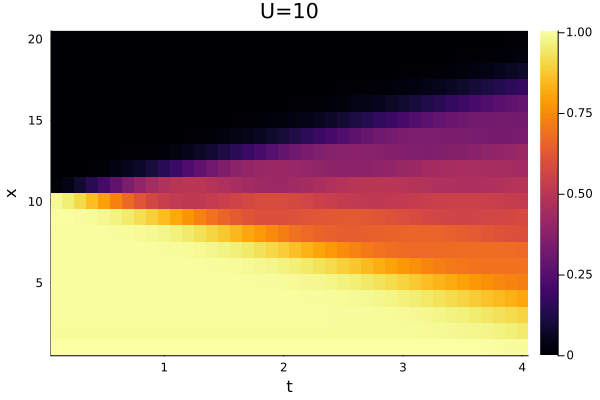

In [5]:
@time mod10=tdvpexp(;num=10,trap=well(20;V=30,L=10.5,s=0),
    U=10,time_step=0.1,T=4,maxn=3,verbose=true,
    outputlevel=1,redirectstdout="mod10.out",dg=0.1,dU=0.05,ω=10);
saveocs(mod10,"mod10.hdf5")
densityheatmap("mod10.hdf5";title="U=10")

In [7]:
if !(isdir("medosc"))
    mkdir("medosc")
end

In [9]:
round(Int,0.92*10)

9

In [12]:
isdir(".")

true

In [43]:
include("1DExpansionScripts.jl")

prodwUexpscript (generic function with 1 method)

Lets test the script writer

In [44]:
fastoscscripts=[scaledexpmodscript("fast";dir="fast",U,ωlist=0:0.1:0.2,dU=0.05,dg=0.1,
        num=10,len=20,V=30,time_step=0.1,T=4,maxdim=1000)
    for U in 0:0.2:0.4]
fastmaster=masterscript("fastmaster",fastoscscripts)

"fastmaster"

In [18]:
Uvals=vcat(0:0.1:0.9,1:10)

20-element Vector{Float64}:
  0.0
  0.1
  0.2
  0.3
  0.4
  0.5
  0.6
  0.7
  0.8
  0.9
  1.0
  2.0
  3.0
  4.0
  5.0
  6.0
  7.0
  8.0
  9.0
 10.0

In [19]:
wvals=0:0.1:10

0.0:0.1:10.0

In [48]:
100*20/60/60

0.5555555555555556

In [46]:
medoscscripts=[scaledexpmodscript("mo";dir="med",U=U,ωlist=wvals,
        dU=0.05,dg=0.1,num=20,len=40,V=30,time_step=0.1,T=10,maxdim=2000)
    for U in Uvals]
medoscmaster=masterscript("medoscmaster",medoscscripts)

"medoscmaster"

In [15]:
[x+y for x in 1:10 for y in 1:10]

100-element Vector{Int64}:
  2
  3
  4
  5
  6
  7
  8
  9
 10
 11
  3
  4
  5
  ⋮
 18
 19
 11
 12
 13
 14
 15
 16
 17
 18
 19
 20